# Pillar 1 — Economics: The Make-Up Time Phenomenon
**Question:** When a flight departs late, what operational factors determine whether an airline recovers that lost time?

**Pipeline:** Univariate EDA → Multivariate EDA → Nonlinearity Check → Random Forest → SHAP

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import shap
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE   = {'Mainline': '#1f77b4', 'Regional': '#ff7f0e'}
DAY_NAMES   = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
MONTH_NAMES = {1:'Jan', 2:'Feb', 6:'Jun', 7:'Jul', 9:'Sep', 10:'Oct'}   # updated dataset months
MONTH_ORDER = list(MONTH_NAMES.values())
TIME_ORDER = ['Morning', 'Afternoon', 'Evening', 'Night']

CHARTS = os.path.join(os.getcwd(), '..', 'charts', 'pillar1')
os.makedirs(CHARTS, exist_ok=True)
def save(name): plt.savefig(os.path.join(CHARTS, name), bbox_inches='tight'); plt.show()

df = pd.read_parquet(os.path.join(os.getcwd(), '..', 'data', 'cleaned_flight_data_2024.parquet'))

df = df[df['Carrier_Type'] != 'ULCC'].copy()
df['Carrier_Type'] = df['Carrier_Type'].cat.remove_unused_categories()

df['DayName']   = df['DayOfWeek'].map(DAY_NAMES)
df['MonthName'] = df['Month'].map(MONTH_NAMES)          # map numeric month → abbreviated name

df_d = df[df['DepDelay'] > 15].copy()
df_d['Distance_Band'] = pd.cut(
    df_d['Distance'], bins=[0, 500, 1500, 9999],
    labels=['Short (<500mi)', 'Medium (500-1500mi)', 'Long (>1500mi)']
)

print(f'Total flights     : {len(df):,}')
print(f'Delayed (>15 min) : {len(df_d):,}  ({len(df_d)/len(df)*100:.1f}%)')

Total flights     : 3,159,061
Delayed (>15 min) : 611,940  (19.4%)


---
## Stage 1 — EDA
### 1A: Univariate — Shape of the outcome variable

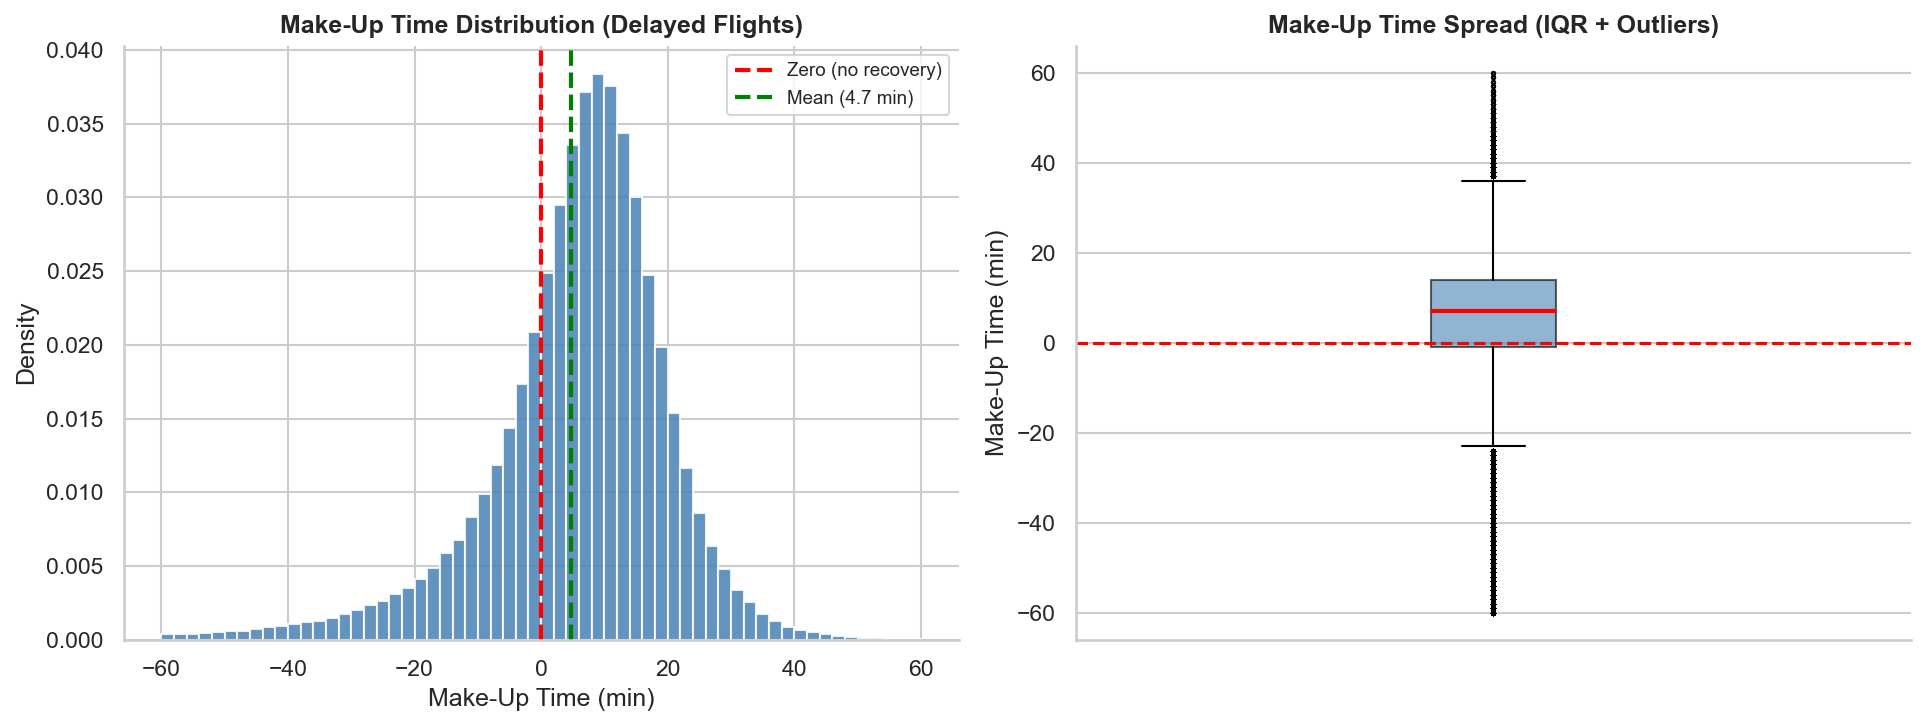

count    611940.00
mean          4.67
std          16.59
min        -292.00
25%          -1.00
50%           7.00
75%          14.00
max         133.00
Name: Make_Up_Time, dtype: float64

% recovered (>0) : 70.9%
% worsened  (<0) : 26.8%


In [2]:
# Distribution of Make-Up Time
sub = df_d[df_d['Make_Up_Time'].between(-60, 60)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(sub['Make_Up_Time'], bins=60, color='steelblue',
             edgecolor='white', alpha=0.85, density=True)
axes[0].axvline(0, color='red', linestyle='--', lw=2, label='Zero (no recovery)')
axes[0].axvline(df_d['Make_Up_Time'].mean(), color='green', linestyle='--', lw=2,
                label=f"Mean ({df_d['Make_Up_Time'].mean():.1f} min)")
axes[0].set_title('Make-Up Time Distribution (Delayed Flights)', fontweight='bold')
axes[0].set_xlabel('Make-Up Time (min)'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

axes[1].boxplot(sub['Make_Up_Time'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', lw=2),
                flierprops=dict(marker='.', alpha=0.1, markersize=3))
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Make-Up Time Spread (IQR + Outliers)', fontweight='bold')
axes[1].set_ylabel('Make-Up Time (min)'); axes[1].set_xticks([])

plt.tight_layout()
save('p1_uni_distribution.png')

print(df_d['Make_Up_Time'].describe().round(2))
print(f"\n% recovered (>0) : {(df_d['Make_Up_Time']>0).mean()*100:.1f}%")
print(f"% worsened  (<0) : {(df_d['Make_Up_Time']<0).mean()*100:.1f}%")

### 1B: Multivariate — How Make-Up Time behaves across operational dimensions

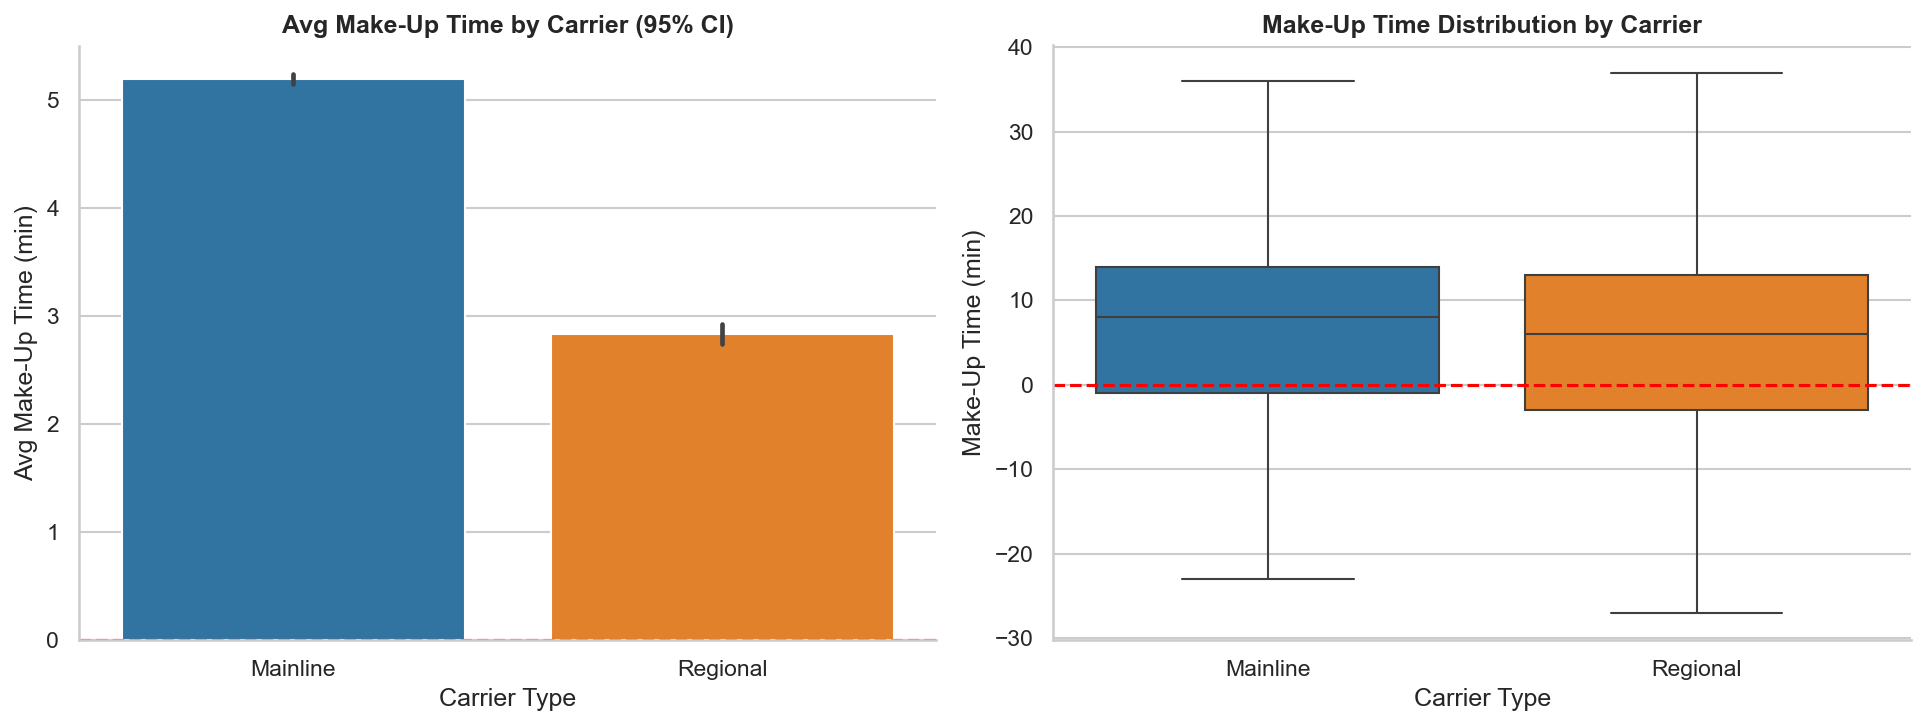

In [3]:
# Make-Up Time by Carrier Type — bar (mean + CI) and box (distribution)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=df_d, x='Carrier_Type', y='Make_Up_Time',
            order=['Mainline','Regional'], palette=PALETTE,
            errorbar=('ci', 95), ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_title('Avg Make-Up Time by Carrier (95% CI)', fontweight='bold')
axes[0].set_xlabel('Carrier Type')
axes[0].set_ylabel('Avg Make-Up Time (min)')

sns.boxplot(data=df_d[df_d['Make_Up_Time'].between(-60,60)],
            x='Carrier_Type', y='Make_Up_Time',
            order=['Mainline','Regional'], palette=PALETTE,
            showfliers=False, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Make-Up Time Distribution by Carrier', fontweight='bold')
axes[1].set_xlabel('Carrier Type')
axes[1].set_ylabel('Make-Up Time (min)')

plt.tight_layout()
save('p1_multi_carrier.png')

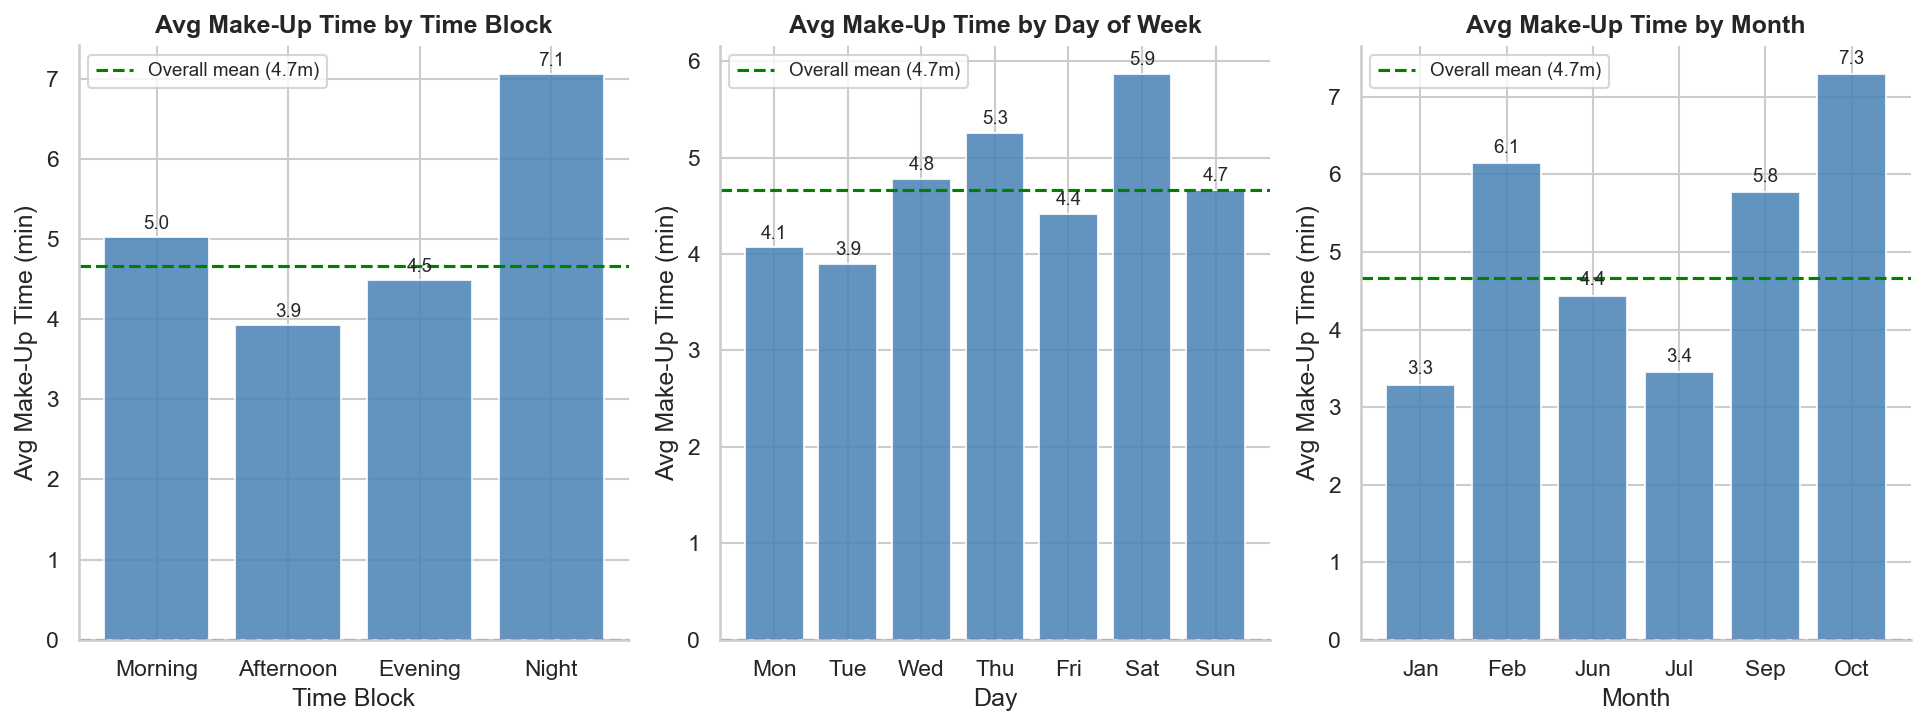

In [4]:
# Make-Up Time by Day of Week and Time Block and Month — bar charts with overall mean line
dow_order = list(DAY_NAMES.values())
dow_all   = df_d.groupby('DayName')['Make_Up_Time'].mean().reindex(dow_order)
dow_ct    = df_d.groupby(['DayName','Carrier_Type'])['Make_Up_Time'].mean().reset_index()
month_all = df_d.groupby('MonthName')['Make_Up_Time'].mean().reindex(MONTH_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

tb_all = df_d.groupby('Time_Block')['Make_Up_Time'].mean().reindex(TIME_ORDER)

axes[0].bar(TIME_ORDER, tb_all.values, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].axhline(df_d['Make_Up_Time'].mean(), color='green', linestyle='--', lw=1.5,
                label=f"Overall mean ({df_d['Make_Up_Time'].mean():.1f}m)")
for i, v in enumerate(tb_all.values):
    axes[0].text(i, v + 0.05, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Avg Make-Up Time by Time Block', fontweight='bold')
axes[0].set_xlabel('Time Block'); axes[0].set_ylabel('Avg Make-Up Time (min)'); axes[0].legend(fontsize=9)

axes[1].bar(dow_order, dow_all.values, color='steelblue', alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].axhline(df_d['Make_Up_Time'].mean(), color='green', linestyle='--', lw=1.5,
                label=f"Overall mean ({df_d['Make_Up_Time'].mean():.1f}m)")
for i, v in enumerate(dow_all.values):
    axes[1].text(i, v + 0.05, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Avg Make-Up Time by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Avg Make-Up Time (min)'); axes[1].legend(fontsize=9)

colors     = ['steelblue' if v >= 0 else 'tomato' for v in month_all.values]
axes[2].bar(MONTH_ORDER, month_all.values, color=colors, alpha=0.85, edgecolor='white')
axes[2].axhline(0, color='red', linestyle='--', lw=1.5)
axes[2].axhline(df_d['Make_Up_Time'].mean(), color='green', linestyle='--', lw=1.5,
                label=f"Overall mean ({df_d['Make_Up_Time'].mean():.1f}m)")
for i, v in enumerate(month_all.values):
    axes[2].text(i, v + (0.08 if v >= 0 else -0.15),
                 f'{v:.1f}', ha='center',
                 va='bottom' if v >= 0 else 'top', fontsize=9)
axes[2].set_title('Avg Make-Up Time by Month', fontweight='bold')
axes[2].set_xlabel('Month'); axes[2].set_ylabel('Avg Make-Up Time (min)')
axes[2].legend(fontsize=9)

plt.tight_layout()
save('p1_multi_dow_time_month.png')

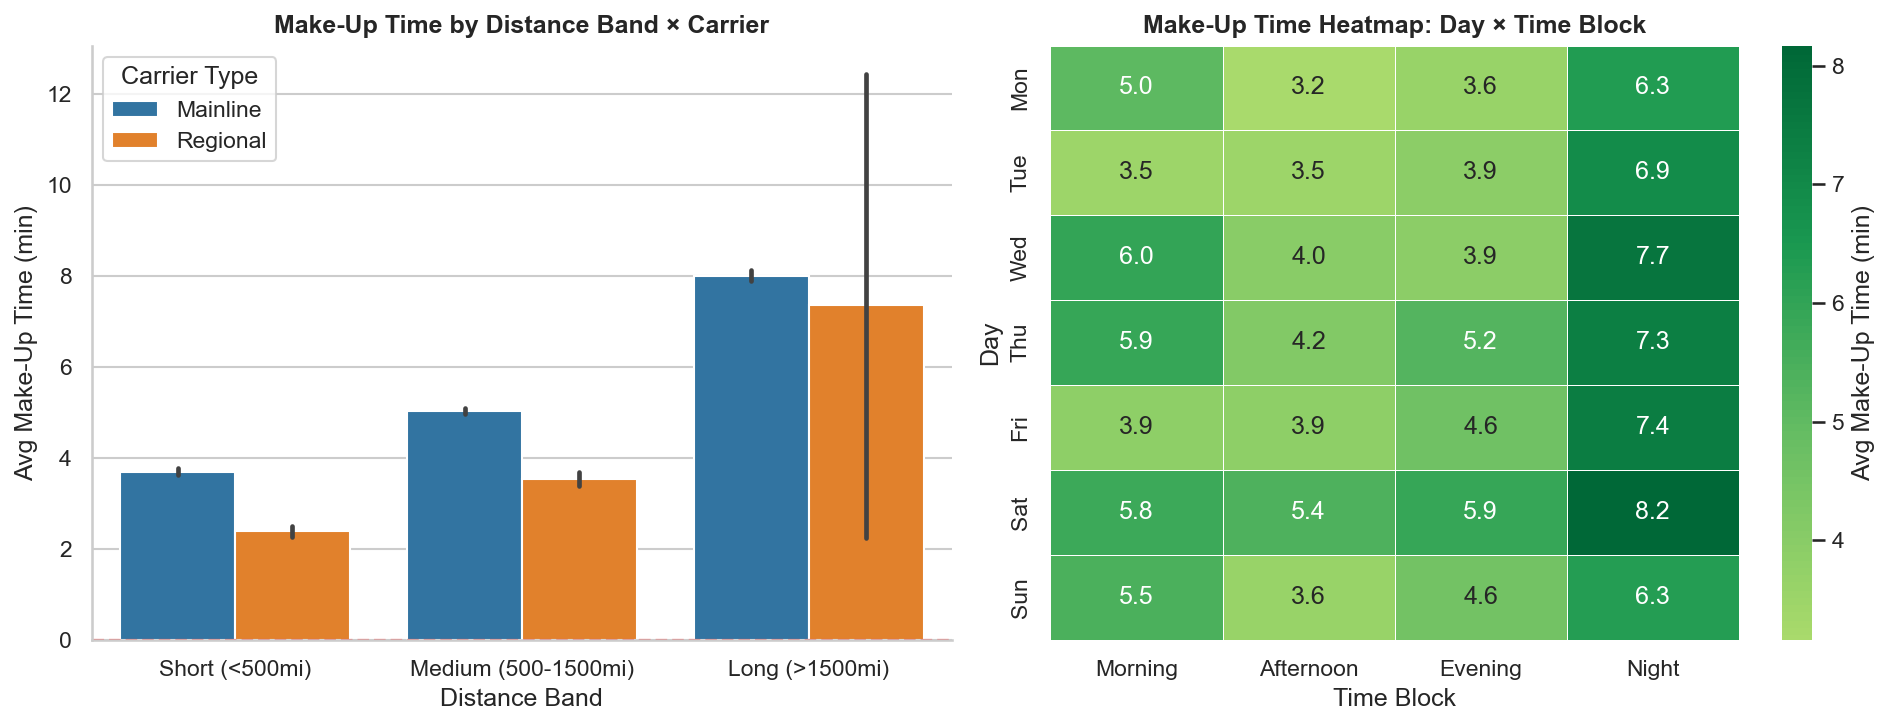

In [5]:
# Distance × Carrier + Day×TimeBlock Heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=df_d, x='Distance_Band', y='Make_Up_Time',
            hue='Carrier_Type', palette=PALETTE,
            errorbar=('ci', 95), ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_title('Make-Up Time by Distance Band × Carrier', fontweight='bold')
axes[0].set_xlabel('Distance Band');
axes[0].set_ylabel('Avg Make-Up Time (min)')
axes[0].legend(title='Carrier Type')

hm = (
    df_d.groupby(['DayName','Time_Block'])['Make_Up_Time']
    .mean().unstack()
    .reindex(index=list(DAY_NAMES.values()), columns=TIME_ORDER)
)
sns.heatmap(hm, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.4, cbar_kws={'label':'Avg Make-Up Time (min)'}, ax=axes[1])
axes[1].set_title('Make-Up Time Heatmap: Day × Time Block', fontweight='bold')
axes[1].set_xlabel('Time Block'); axes[1].set_ylabel('Day')

plt.tight_layout()
save('p1_multi_distance_heatmap.png')

---
## Stage 2 — Nonlinearity Check (LOWESS)
Before modelling, verify the true shape of `DepDelay → Make_Up_Time`.
A curved smoother confirms a threshold effect: small delays go unrecovered,
large delays trigger aggressive recovery due to economic pressure.

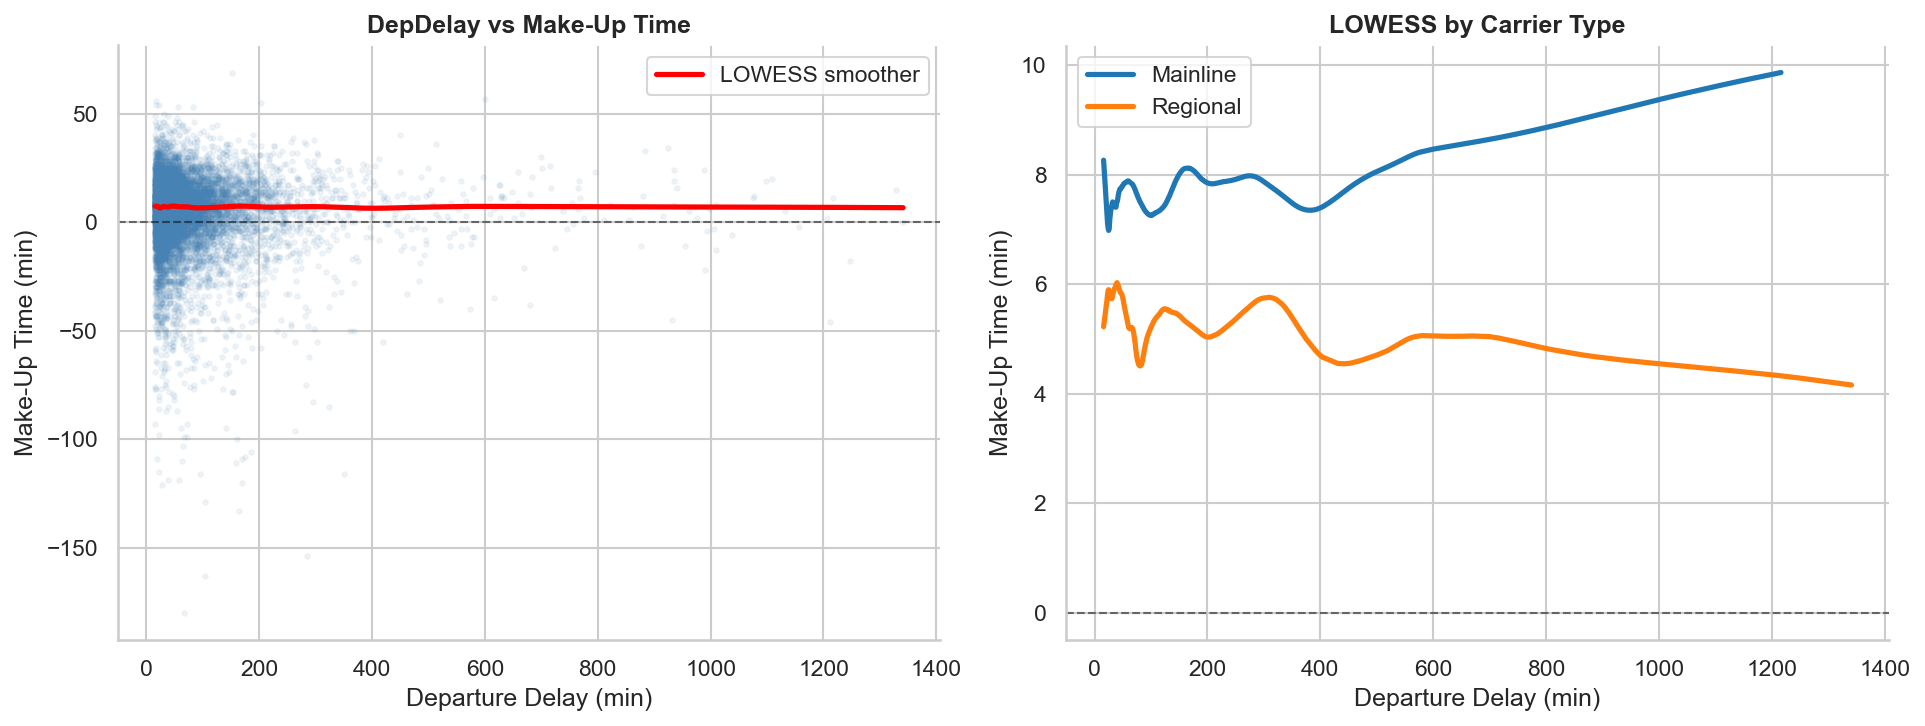

In [6]:
sample = df_d.sample(12_000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(sample['DepDelay'], sample['Make_Up_Time'],
                alpha=0.07, s=5, color='steelblue')
lw = sm.nonparametric.lowess(sample['Make_Up_Time'], sample['DepDelay'], frac=0.2)
axes[0].plot(lw[:,0], lw[:,1], color='red', lw=2.5, label='LOWESS smoother')
axes[0].axhline(0, color='black', linestyle='--', lw=1, alpha=0.5)
axes[0].set_title('DepDelay vs Make-Up Time', fontweight='bold')
axes[0].set_xlabel('Departure Delay (min)'); axes[0].set_ylabel('Make-Up Time (min)')
axes[0].legend()

for ct in ['Mainline', 'Regional']:
    g   = sample[sample['Carrier_Type'] == ct]
    lwc = sm.nonparametric.lowess(g['Make_Up_Time'], g['DepDelay'], frac=0.3)
    axes[1].plot(lwc[:,0], lwc[:,1], color=PALETTE[ct], lw=2.5, label=ct)
axes[1].axhline(0, color='black', linestyle='--', lw=1, alpha=0.5)
axes[1].set_title('LOWESS by Carrier Type',
                  fontweight='bold')
axes[1].set_xlabel('Departure Delay (min)'); axes[1].set_ylabel('Make-Up Time (min)')
axes[1].legend()

plt.tight_layout()
save('p1_lowess.png')

---
## Stage 3 — Random Forest
LOWESS confirms nonlinearity → Random Forest captures threshold effects without assumptions.
Features mirror what an airline dispatcher observes when making recovery decisions.

In [7]:
rf_df  = df_d[['Make_Up_Time','DepDelay','Distance',
               'Carrier_Type','Time_Block','DayOfWeek']].dropna().copy()
rf_enc = pd.get_dummies(rf_df, columns=['Carrier_Type','Time_Block'], drop_first=False)

FEATURES = [c for c in rf_enc.columns if c != 'Make_Up_Time']
X = rf_enc[FEATURES]
y = rf_enc['Make_Up_Time']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=300, max_depth=15,
                           min_samples_leaf=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)

print(f"Random Forest — Test Set")
print(f"  RMSE : {rmse:.3f} min")
print(f"  MAE  : {mae:.3f} min")
print(f"  R²   : {r2:.4f}")

Random Forest — Test Set
  RMSE : 16.321 min
  MAE  : 11.106 min
  R²   : 0.0261


---
## Stage 4 — SHAP: Targeted Insights
1. **Which features matter and in what direction**
2. **The economic threshold** — at what delay size does recovery kick in
3. **The carrier advantage** — mainline vs regional, after controlling for everything

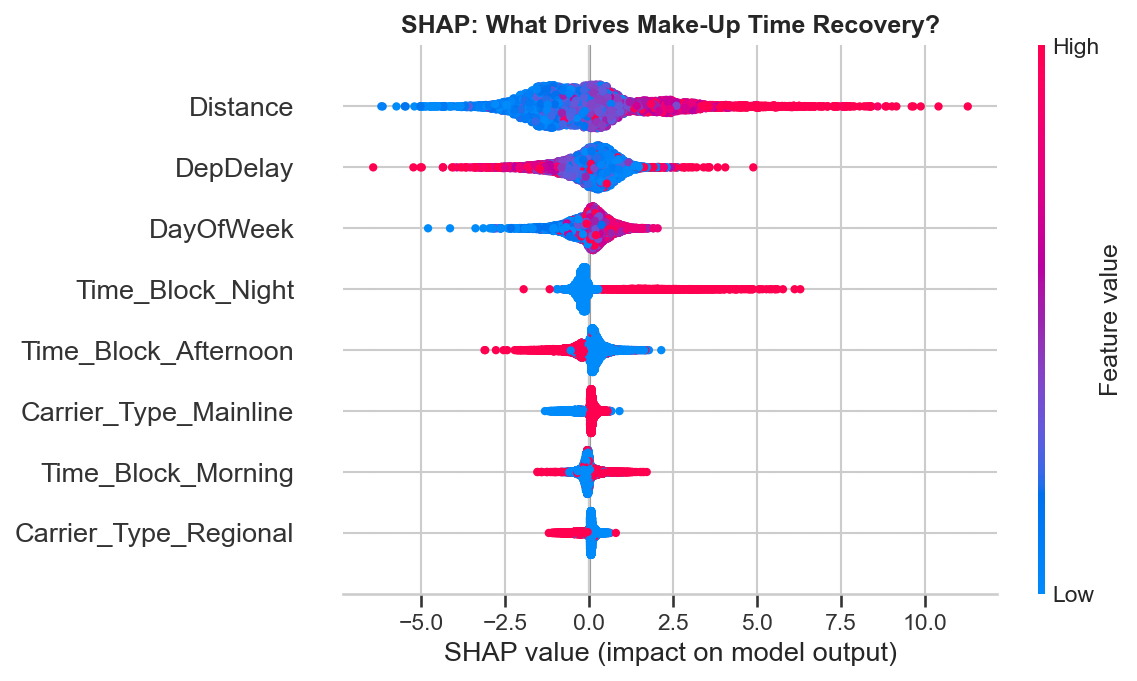

In [8]:
# SHAP values for feature importance and partial dependence
shap_sample = X_test.sample(10000, random_state=42)
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, shap_sample, plot_type='dot',
                  max_display=8, show=False)
plt.title('SHAP: What Drives Make-Up Time Recovery?', fontsize=12, fontweight='bold')
plt.tight_layout()
save('p1_shap_summary.png')

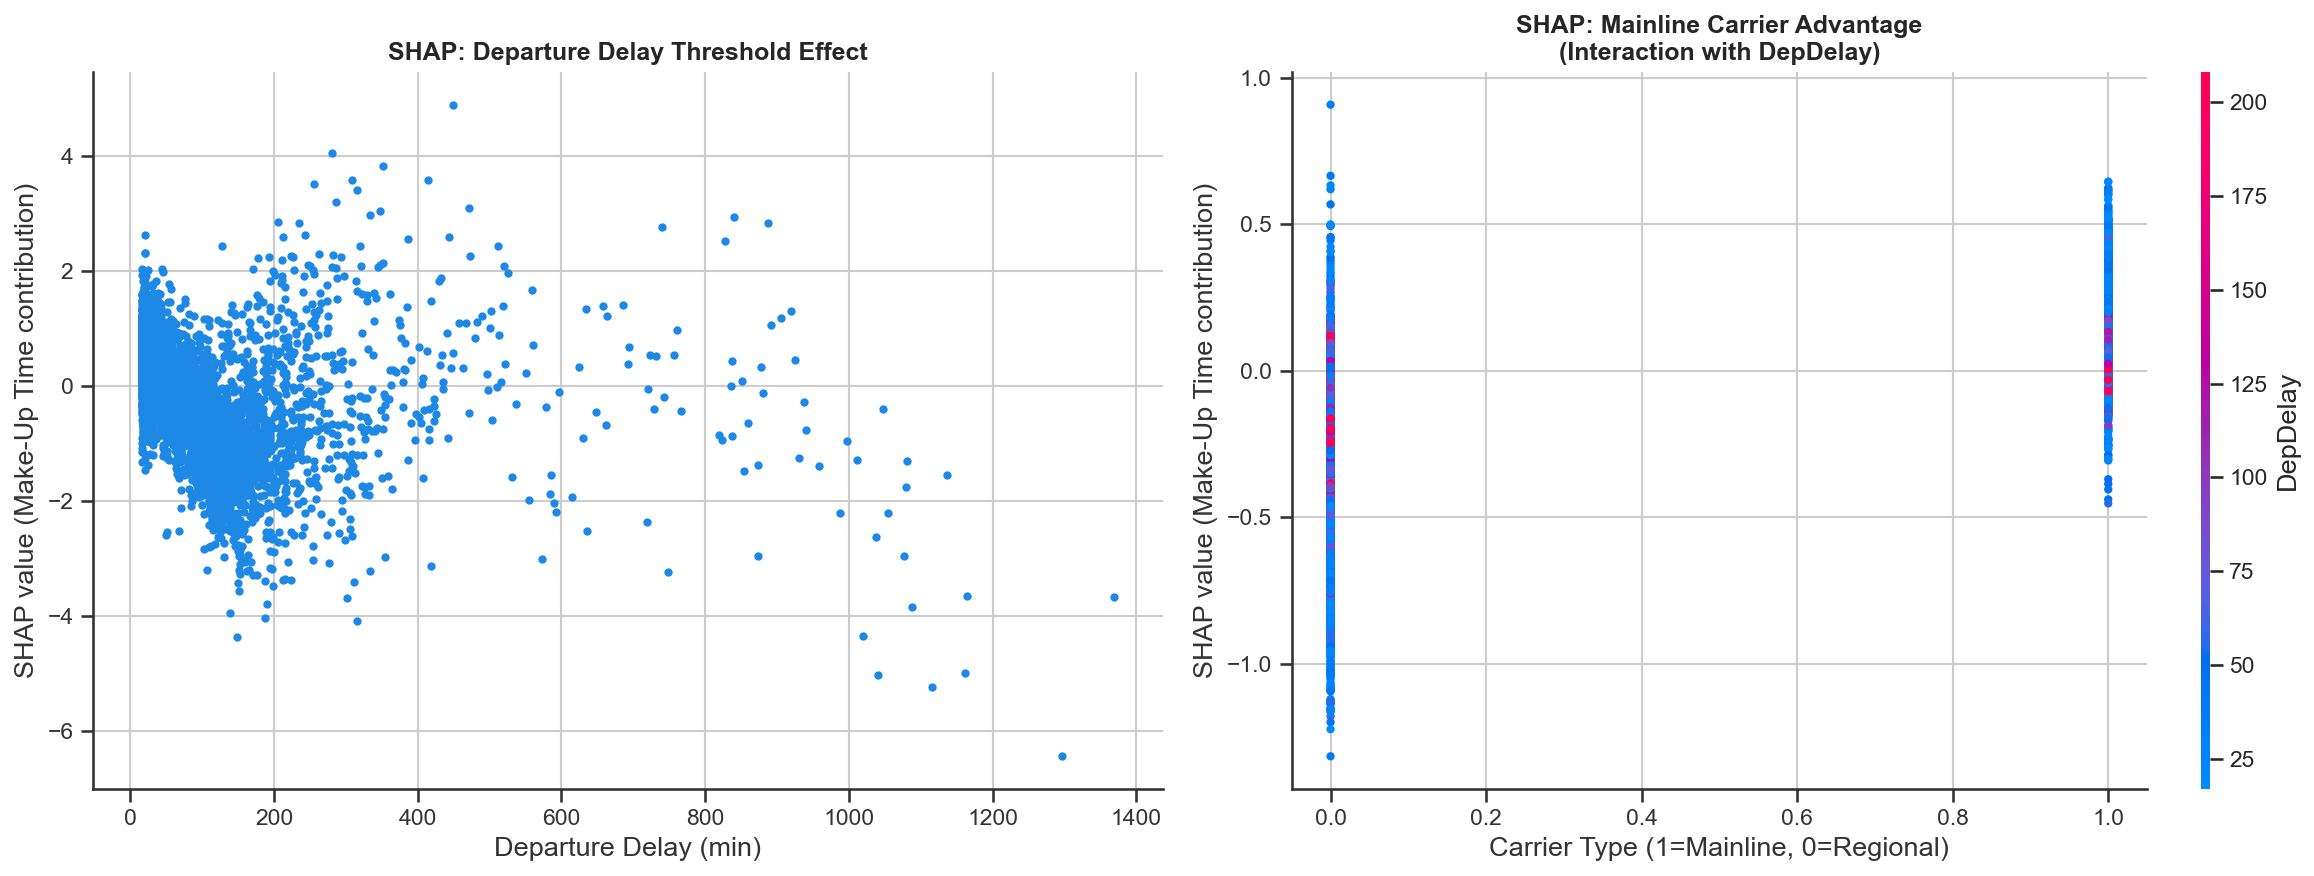

In [9]:
# Create the figure grid
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Threshold Effect
shap.dependence_plot('DepDelay', shap_values, shap_sample,
                     interaction_index=None, 
                     show=False, 
                     ax=ax[0])
ax[0].set_title('SHAP: Departure Delay Threshold Effect', fontweight='bold')
ax[0].set_xlabel('Departure Delay (min)')
ax[0].set_ylabel('SHAP value (Make-Up Time contribution)')

# Carrier Advantage
carrier_col = 'Carrier_Type_Mainline'
if carrier_col in shap_sample.columns:
    shap.dependence_plot(carrier_col, shap_values, shap_sample,
                         interaction_index='DepDelay', 
                         show=False, 
                         ax=ax[1])
    
    ax[1].set_title('SHAP: Mainline Carrier Advantage\n(Interaction with DepDelay)', fontweight='bold')
    ax[1].set_xlabel('Carrier Type (1=Mainline, 0=Regional)')
    ax[1].set_ylabel('SHAP value (Make-Up Time contribution)')
else:
    ax[1].text(0.5, 0.5, f'Column "{carrier_col}" missing', 
               ha='center', va='center', fontsize=12, color='red')

plt.tight_layout()
save('p1_shap_insights.png')

In [10]:
m = df_d.groupby('Carrier_Type')['Make_Up_Time'].mean()

print("PILLAR 1 — RESULTS SUMMARY")
print(f"Flights recovered time (>0)  : {(df_d['Make_Up_Time']>0).mean()*100:.1f}%")
print(f"Mainline avg make-up time    : {m['Mainline']:.2f} min")
print(f"Regional avg make-up time    : {m['Regional']:.2f} min")
print(f"Raw gap (Mainline − Regional): {m['Mainline']-m['Regional']:.2f} min")
print(f"RF  R²                       : {r2:.4f}")
print(f"RF  RMSE                     : {rmse:.3f} min")

PILLAR 1 — RESULTS SUMMARY
Flights recovered time (>0)  : 70.9%
Mainline avg make-up time    : 5.20 min
Regional avg make-up time    : 2.83 min
Raw gap (Mainline − Regional): 2.36 min
RF  R²                       : 0.0261
RF  RMSE                     : 16.321 min
